In [13]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 设置图形样式
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("中文字体配置完成！")


中文字体配置完成！


当前系统: Darwin
使用中文字体: Arial Unicode MS


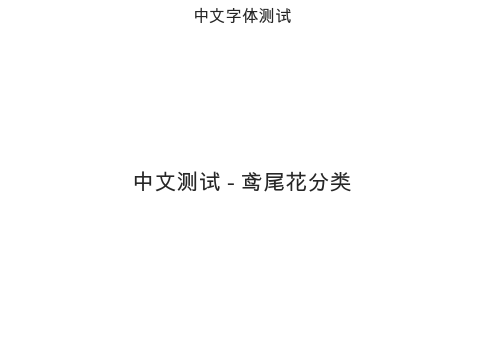

In [14]:
# 检查可用的中文字体并设置最佳选项
import platform
from matplotlib import font_manager

print(f"当前系统: {platform.system()}")

# 查找系统中可用的中文字体
available_fonts = [f.name for f in font_manager.fontManager.ttflist]
chinese_fonts = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'PingFang SC', 'Heiti SC']

found_font = None
for font in chinese_fonts:
    if font in available_fonts:
        found_font = font
        break

if found_font:
    plt.rcParams['font.sans-serif'] = [found_font]
    print(f"使用中文字体: {found_font}")
else:
    print("未找到中文字体，使用默认字体")
    # 尝试使用系统默认字体
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# 确保负号正常显示
plt.rcParams['axes.unicode_minus'] = False

# 测试中文显示
plt.figure(figsize=(6, 4))
plt.text(0.5, 0.5, '中文测试 - 鸢尾花分类', fontsize=16, ha='center', va='center')
plt.title('中文字体测试')
plt.axis('off')
plt.show()


In [2]:
# 加载鸢尾花数据集
iris = load_iris()
X = iris.data
y = iris.target

# 创建DataFrame以便更好地查看数据
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("数据集基本信息：")
print(f"样本数量: {len(df)}")
print(f"特征数量: {len(iris.feature_names)}")
print(f"类别数量: {len(iris.target_names)}")
print(f"类别名称: {iris.target_names}")

print("\n数据前5行：")
print(df.head())

print("\n数据统计信息：")
print(df.describe())


数据集基本信息：
样本数量: 150
特征数量: 4
类别数量: 3
类别名称: ['setosa' 'versicolor' 'virginica']

数据前5行：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

数据统计信息：
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000         

In [3]:
# 检查类别分布
print("各类别样本数量：")
print(df['species'].value_counts())

# 检查是否有缺失值
print(f"\n缺失值数量: {df.isnull().sum().sum()}")


各类别样本数量：
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

缺失值数量: 0


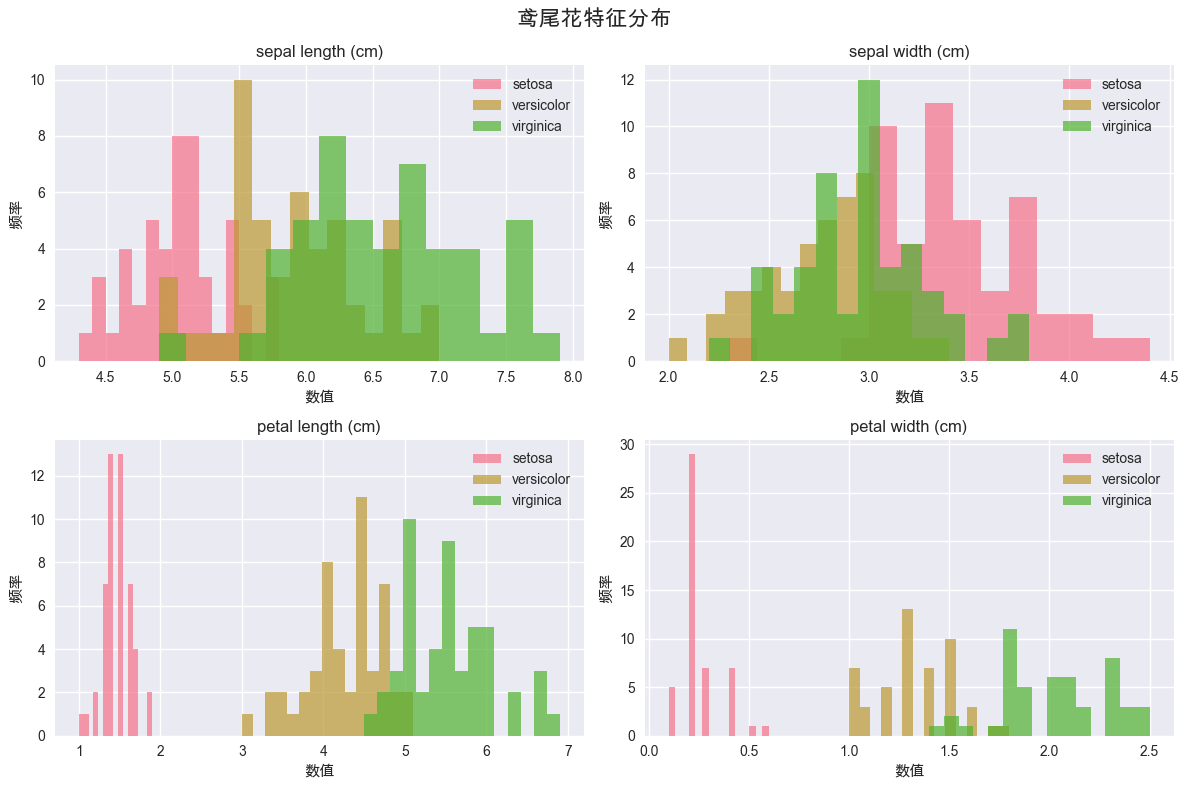

In [15]:
# 创建特征分布图
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('鸢尾花特征分布', fontsize=16)

for i, feature in enumerate(iris.feature_names):
    row = i // 2
    col = i % 2
    
    for species in df['species'].unique():
        data = df[df['species'] == species][feature]
        axes[row, col].hist(data, alpha=0.7, label=species, bins=15)
    
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('数值')
    axes[row, col].set_ylabel('频率')
    axes[row, col].legend()

plt.tight_layout()
plt.show()


<Figure size 1000x800 with 0 Axes>

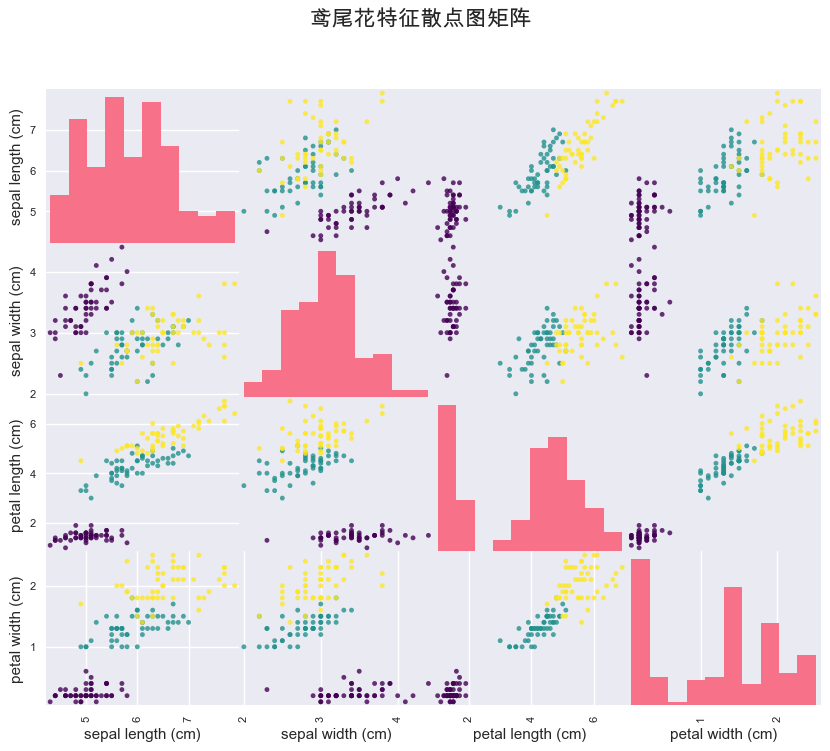

In [16]:
# 创建散点图矩阵
plt.figure(figsize=(10, 8))
pd.plotting.scatter_matrix(df.iloc[:, :-2], c=df['target'], 
                          figsize=(10, 8), alpha=0.8, cmap='viridis')
plt.suptitle('鸢尾花特征散点图矩阵', fontsize=16)
plt.show()


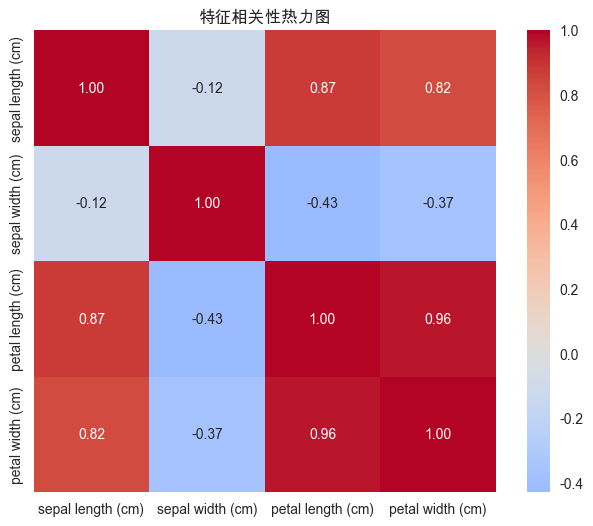

In [17]:
# 创建相关性热力图
plt.figure(figsize=(8, 6))
correlation_matrix = df.iloc[:, :-2].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('特征相关性热力图')
plt.show()


In [18]:
# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")
print(f"训练集类别分布: {np.bincount(y_train)}")
print(f"测试集类别分布: {np.bincount(y_test)}")


训练集大小: 105
测试集大小: 45
训练集类别分布: [35 35 35]
测试集类别分布: [15 15 15]


In [8]:
# 训练多个模型进行比较
models = {
    '随机森林': RandomForestClassifier(n_estimators=100, random_state=42),
    '逻辑回归': LogisticRegression(random_state=42, max_iter=200),
    '支持向量机': SVC(random_state=42, probability=True)
}

# 训练模型并记录结果
results = {}

for name, model in models.items():
    print(f"正在训练 {name}...")
    model.fit(X_train, y_train)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} 准确率: {accuracy:.4f}")

print("\n模型训练完成！")


正在训练 随机森林...
随机森林 准确率: 0.8889
正在训练 逻辑回归...
逻辑回归 准确率: 0.9333
正在训练 支持向量机...
支持向量机 准确率: 0.9556

模型训练完成！


In [9]:
# 找出最佳模型
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"最佳模型: {best_model_name}")
print(f"最佳准确率: {results[best_model_name]['accuracy']:.4f}")

print(f"\n{best_model_name} 详细分类报告:")
print(classification_report(y_test, best_predictions, 
                          target_names=iris.target_names))


最佳模型: 支持向量机
最佳准确率: 0.9556

支持向量机 详细分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



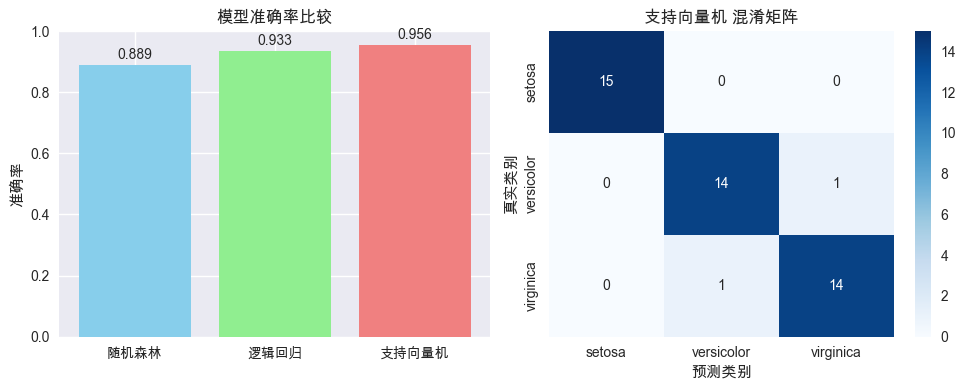

In [19]:
# 创建混淆矩阵
plt.figure(figsize=(10, 4))

# 绘制所有模型的准确率比较
plt.subplot(1, 2, 1)
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('模型准确率比较')
plt.ylabel('准确率')
plt.ylim(0, 1)

# 在柱状图上显示数值
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 绘制最佳模型的混淆矩阵
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title(f'{best_model_name} 混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')

plt.tight_layout()
plt.show()


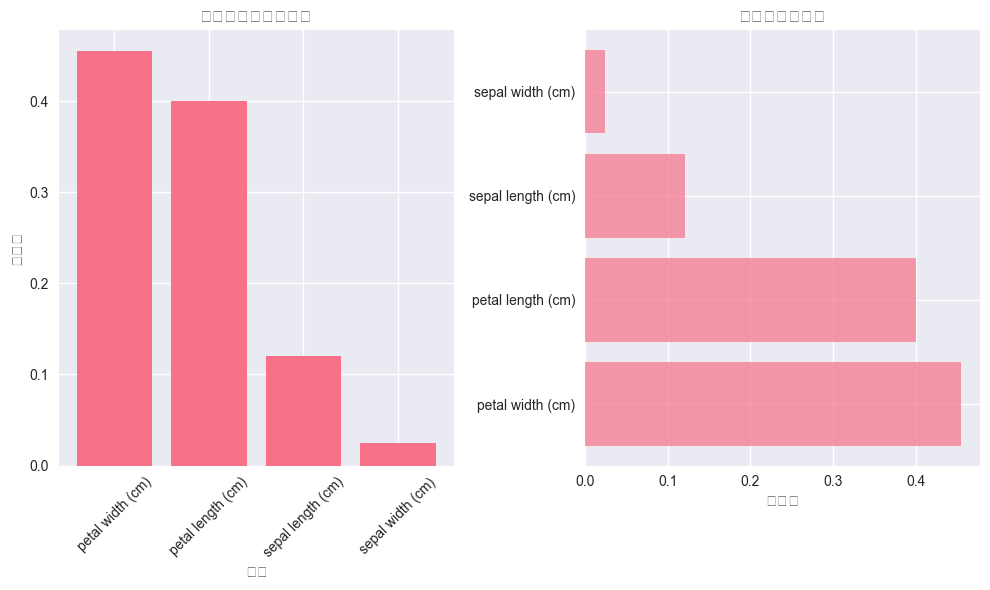

特征重要性排序:
1. petal width (cm): 0.4549
2. petal length (cm): 0.4002
3. sepal length (cm): 0.1206
4. sepal width (cm): 0.0243


In [11]:
# 分析随机森林的特征重要性（如果随机森林是最佳模型）
if '随机森林' in results:
    rf_model = results['随机森林']['model']
    feature_importance = rf_model.feature_importances_
    
    # 创建特征重要性图
    plt.figure(figsize=(10, 6))
    
    # 特征重要性柱状图
    plt.subplot(1, 2, 1)
    indices = np.argsort(feature_importance)[::-1]
    plt.bar(range(len(feature_importance)), feature_importance[indices])
    plt.title('随机森林特征重要性')
    plt.xlabel('特征')
    plt.ylabel('重要性')
    plt.xticks(range(len(feature_importance)), 
               [iris.feature_names[i] for i in indices], rotation=45)
    
    # 特征重要性水平条形图
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(iris.feature_names))
    plt.barh(y_pos, feature_importance[indices], alpha=0.7)
    plt.yticks(y_pos, [iris.feature_names[i] for i in indices])
    plt.xlabel('重要性')
    plt.title('特征重要性排序')
    
    plt.tight_layout()
    plt.show()
    
    print("特征重要性排序:")
    for i, idx in enumerate(indices):
        print(f"{i+1}. {iris.feature_names[idx]}: {feature_importance[idx]:.4f}")
else:
    print("随机森林不在训练的模型中，无法显示特征重要性。")


In [12]:
# 使用最佳模型进行新样本预测
print("使用最佳模型进行预测示例:")
print(f"使用模型: {best_model_name}")

# 创建一些示例数据进行预测
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],  # 可能是 setosa
    [6.2, 2.8, 4.8, 1.8],  # 可能是 versicolor  
    [7.2, 3.2, 6.0, 1.8]   # 可能是 virginica
])

# 进行预测
predictions = best_model.predict(new_samples)
probabilities = best_model.predict_proba(new_samples)

print("\n预测结果:")
for i, (sample, pred, prob) in enumerate(zip(new_samples, predictions, probabilities)):
    print(f"\n样本 {i+1}: {sample}")
    print(f"预测类别: {iris.target_names[pred]}")
    print(f"预测概率:")
    for j, species in enumerate(iris.target_names):
        print(f"  {species}: {prob[j]:.3f}")

print(f"\n总结:")
print(f"本次机器学习案例使用了 {len(models)} 个不同的分类算法")
print(f"最佳模型是 {best_model_name}，在测试集上达到了 {results[best_model_name]['accuracy']:.1%} 的准确率")
print("这个结果表明我们的模型能够很好地识别不同种类的鸢尾花！")


使用最佳模型进行预测示例:
使用模型: 支持向量机

预测结果:

样本 1: [5.1 3.5 1.4 0.2]
预测类别: setosa
预测概率:
  setosa: 0.967
  versicolor: 0.022
  virginica: 0.012

样本 2: [6.2 2.8 4.8 1.8]
预测类别: virginica
预测概率:
  setosa: 0.013
  versicolor: 0.448
  virginica: 0.540

样本 3: [7.2 3.2 6.  1.8]
预测类别: virginica
预测概率:
  setosa: 0.012
  versicolor: 0.013
  virginica: 0.975

总结:
本次机器学习案例使用了 3 个不同的分类算法
最佳模型是 支持向量机，在测试集上达到了 95.6% 的准确率
这个结果表明我们的模型能够很好地识别不同种类的鸢尾花！
